In [ ]:
import os, time, random, json
import numpy as np
import urllib.request, zipfile

# Silence TF info / warning messages; keep only errors.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping # ReduceLROnPlateau,

# Reproducibility - Fix all random seeds so results are reproducible across runs.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Configuration - Central dictionary – change values here; nothing else needs editing.

CFG = {
    "num_classes":      46,      # DHCD: 36 consonants + 10 digits
    "image_size":       32,      # resize every image to 64×64 px
    "batch_size":       64,
    "epochs":           100,
    "lr":               5e-4,    # peak learning rate for cosine schedule
    "weight_decay":     1e-4,    # AdamW L2 regularisation
    "label_smoothing":  0.1,     # prevents over-confident softmax outputs
    "val_split":        0.1,     # fraction of training data held for validation
    # "data_dir":         "./data/DHCD",
    "data_dir":         "/kaggle/input/datasets/rautranjit/devanagari/DevanagariHandwrittenCharacterDataset",
    "results_dir":      "./results",
}

os.makedirs(CFG["results_dir"], exist_ok=True)
NUM_CLASSES = CFG["num_classes"]
IMG         = CFG["image_size"]
BS          = CFG["batch_size"]
AUTOTUNE    = tf.data.AUTOTUNE

# Dataset download & pipeline

# os.makedirs("./data", exist_ok=True)
# zip_path = "./data/DHCD.zip"
zip_path = "/kaggle/input/datasets/theranjitraut/devanagari/DevanagariHandwrittenCharacterDataset"

if os.path.exists(CFG["data_dir"]):
    print("[INFO] DHCD already present – skipping download.")
else:
    print("[INFO] Downloading DHCD …")
    try:
        # urllib.request.urlretrieve(_DHCD_URL, zip_path)
        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall("./data/")
        os.rename("./data/DevanagariHandwrittenCharacterDataset", CFG["data_dir"])
        print("[INFO] DHCD extracted successfully.")
    except Exception as exc:
        print(f"[WARN] Download failed: {exc}")

# Load raw (unbatched) tf.data datasets
train_full = keras.utils.image_dataset_from_directory(
    os.path.join(CFG["data_dir"], "Train"),
    image_size=(IMG, IMG), batch_size=None,
    color_mode="grayscale", label_mode="int", seed=SEED,
)
test_ds_raw = keras.utils.image_dataset_from_directory(
    os.path.join(CFG["data_dir"], "Test"),
    image_size=(IMG, IMG), batch_size=None,
    color_mode="grayscale", label_mode="int", seed=SEED,
)

total   = tf.data.experimental.cardinality(train_full).numpy()
n_val   = max(1, int(total * CFG["val_split"]))
n_train = total - n_val

train_ds_raw = train_full.take(n_train)
val_ds_raw   = train_full.skip(n_train)

# Preprocessing helpers
def normalise(img, lbl):
    """Scale pixels from [0, 255] → [-1, 1]."""
    img = tf.cast(img, tf.float32) / 127.5 - 1.0
    return img, lbl

def augment(img, lbl):
    """
    Light stochastic augmentation applied only during training.
    Pad-then-crop gives a random translation effect.
    """
    img = tf.image.random_brightness(img, 0.2)
    img = tf.image.random_contrast(img, 0.8, 1.2)
    img = tf.pad(img, [[2, 2], [2, 2], [0, 0]], constant_values=-1.0)
    img = tf.image.random_crop(img, [IMG, IMG, 1])
    return img, lbl

def to_onehot(img, lbl):
    """
    Convert integer class index → one-hot vector.
    Required because keras.losses.CategoricalCrossentropy expects one-hot
    targets, while SparseCategoricalCrossentropy does NOT support the
    label_smoothing argument.
    """
    return img, tf.one_hot(lbl, NUM_CLASSES)

# Build tf.data pipelines
train_ds = (
    train_ds_raw
    .map(normalise,  num_parallel_calls=AUTOTUNE)
    .map(augment,    num_parallel_calls=AUTOTUNE)
    .map(to_onehot,  num_parallel_calls=AUTOTUNE)
    .shuffle(8192, seed=SEED)
    .batch(BS)
    .prefetch(AUTOTUNE)
)
val_ds = (
    val_ds_raw
    .map(normalise,  num_parallel_calls=AUTOTUNE)
    .map(to_onehot,  num_parallel_calls=AUTOTUNE)
    .batch(BS)
    .prefetch(AUTOTUNE)
)
# Integer-label test set → used for manual macro-F1 calculation.
test_ds = (
    test_ds_raw
    .map(normalise, num_parallel_calls=AUTOTUNE)
    .batch(BS)
    .prefetch(AUTOTUNE)
)
# One-hot test set → used for model.evaluate() (loss + accuracy).
test_ds_oh = (
    test_ds_raw
    .map(normalise,  num_parallel_calls=AUTOTUNE)
    .map(to_onehot,  num_parallel_calls=AUTOTUNE)
    .batch(BS)
    .prefetch(AUTOTUNE)
)

print(f"[INFO] Train: {n_train:,} | Val: {n_val:,} | Test: (batched)")


# Display utilities - Rich terminal output: parameter tables and per-epoch progress bars.
# ANSI colour codes (fall back gracefully on Windows terminals without VT mode)
_COL = {
    "reset":  "\033[0m",
    "bold":   "\033[1m",
    "cyan":   "\033[96m",
    "yellow": "\033[93m",
    "green":  "\033[92m",
    "red":    "\033[91m",
    "grey":   "\033[90m",
    "white":  "\033[97m",
    "blue":   "\033[94m",
}

def _c(text, *codes):
    """Wrap text in one or more ANSI codes."""
    prefix = "".join(_COL.get(c, "") for c in codes)
    return f"{prefix}{text}{_COL['reset']}"


def print_model_summary(model: Model) -> None:
    """
    Print a compact parameter table for a Keras model.
    Groups layers by trainable / non-trainable and shows totals.
    """
    W = 62   # table width
    sep = "─" * W

    trainable     = model.count_params()
    non_trainable = sum(
        tf.size(w).numpy() for w in model.non_trainable_weights
    )
    total = trainable + non_trainable

    # Header
    title = f"  {model.name}  –  Parameter Summary"
    print(f"\n{_c('╔' + '═'*W + '╗', 'cyan')}")
    print(_c(f"║{title:<{W}}║", "cyan", "bold"))
    print(_c(f"╠{'═'*18}╦{'═'*23}╦{'═'*18}╣", "cyan"))
    hdr = f"║  {'Layer':<16}║  {'Type':<21}║  {'Params':>15}  ║"
    print(_c(hdr, "cyan", "bold"))
    print(_c(f"╠{'═'*18}╬{'═'*23}╬{'═'*18}╣", "cyan"))

    # Up to 20 layers to keep output compact
    shown_layers = [l for l in model.layers if l.count_params() > 0][:20]
    for lyr in shown_layers:
        n_params = lyr.count_params()
        row = f"║  {lyr.name[:14]:<16}║  {type(lyr).__name__[:21]:<21}║  {n_params:>15,}  ║"
        print(row)
    if len([l for l in model.layers if l.count_params() > 0]) > 20:
        print(f"║  {'… (truncated)':<16}║  {'':21}║  {'':>15}  ║")

    # Totals footer
    print(_c(f"╠{'═'*18}╩{'═'*23}╩{'═'*18}╣", "cyan"))
    print(_c(f"║  {'Trainable params':<38}: {trainable:>18,}  ║", "green"))
    print(_c(f"║  {'Non-trainable params':<38}: {non_trainable:>18,}  ║", "grey"))
    print(_c(f"║  {'Total params':<38}: {total:>18,}  ║", "bold", "white"))
    print(_c(f"╚{'═'*W}╝", "cyan"))


class EpochProgressCallback(keras.callbacks.Callback):
    """
    Custom Keras callback that prints a compact, colourful progress bar
    after each epoch.
    """

    BAR_WIDTH = 20  # character width of the filled progress bar

    def __init__(self, total_epochs: int, model_name: str):
        super().__init__()
        self.total_epochs = total_epochs
        self.model_name   = model_name
        self._epoch_start = 0.0

    def on_epoch_begin(self, epoch, logs=None):
        self._epoch_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        logs        = logs or {}
        elapsed     = time.time() - self._epoch_start
        ep_num      = epoch + 1
        pct         = ep_num / self.total_epochs
        filled      = int(self.BAR_WIDTH * pct)
        bar         = "█" * filled + "░" * (self.BAR_WIDTH - filled)

        loss    = logs.get("loss",     float("nan"))
        acc     = logs.get("accuracy", float("nan")) * 100
        val_acc = logs.get("val_accuracy", float("nan")) * 100
        val_los = logs.get("val_loss", float("nan"))

        # Retrieve current LR from the optimiser (works for schedule + float)
        try:
            lr_val = float(
                keras.backend.get_value(self.model.optimizer.learning_rate)
            )
            lr_str = f"lr={lr_val:.2e}"
        except Exception:
            lr_str = ""

        epoch_str  = _c(f"Epoch {ep_num:>3}/{self.total_epochs}", "grey")
        bar_str    = _c(bar, "cyan")
        pct_str    = _c(f"{pct*100:>5.1f}%", "yellow")
        loss_str   = _c(f"loss={loss:.4f}", "white")
        acc_str    = _c(f"acc={acc:.2f}%", "green")
        vl_str     = _c(f"val_loss={val_los:.4f}", "white")
        va_str     = _c(f"val_acc={val_acc:.2f}%", "yellow" if val_acc < acc else "green")
        time_str   = _c(f"[{elapsed:.1f}s]", "grey")
        lr_colored = _c(lr_str, "blue")

        print(
            f"  {epoch_str}  {bar_str} {pct_str}  "
            f"{loss_str}  {acc_str}  {vl_str}  {va_str}  "
            f"{lr_colored}  {time_str}"
        )


def print_comparison_table(results: dict) -> None:
    """
    Print a final side-by-side results table for all trained models.
    Highlights the winning model in green.
    """
    W   = 70
    best_name = max(results, key=lambda k: results[k]["test_acc"])

    print(f"\n{_c('╔' + '═'*W + '╗', 'cyan', 'bold')}")
    title = "  FINAL TEST-SET COMPARISON"
    print(_c(f"║{title:<{W}}║", "cyan", "bold"))
    print(_c(f"╠{'═'*24}╦{'═'*12}╦{'═'*12}╦{'═'*12}╦{'═'*6}╣", "cyan"))
    hdr = f"║  {'Model':<22}║{'Params':>11} ║{'Test Acc':>11} ║{'Macro F1':>11} ║{'Loss':>5} ║"
    print(_c(hdr, "bold", "white"))
    print(_c(f"╠{'═'*24}╬{'═'*12}╬{'═'*12}╬{'═'*12}╬{'═'*6}╣", "cyan"))

    for name, r in results.items():
        is_best = (name == best_name)
        color   = "green" if is_best else "white"
        star    = "★" if is_best else " "
        row = (
            f"║{star} {name:<22}║{r['params']:>10,} ║"
            f"{r['test_acc']:>10.2f}%║{r['macro_f1']:>10.2f}%║"
            f"{r['test_loss']:>5.3f} ║"
        )
        print(_c(row, color, "bold") if is_best else row)

    print(_c(f"╚{'═'*24}╩{'═'*12}╩{'═'*12}╩{'═'*12}╩{'═'*6}╝", "cyan"))
    print(_c(f"\n  ★  Winner: {best_name}  ({results[best_name]['test_acc']:.2f}% test accuracy)\n", "green", "bold"))

# Building blocks - Shared sub-modules used by our_model-Net.
def gelu(x):
    """gelu activation – smoother than gelu, better gradients in deep nets."""
    return tf.nn.gelu(x)


def residual_block(x, channels: int):
    """
    Standard pre-activation residual block.
      Conv → BN → gelu → Conv → BN → Add(skip) → gelu
    No channel projection needed because in_channels == out_channels.
    """
    residual = x
    x = layers.Conv2D(channels, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(gelu)(x)
    x = layers.Conv2D(channels, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, residual])
    x = layers.Activation(gelu)(x)
    return x


def dense_res_block(x, in_channels: int, out_channels: int):
    """
    DenseNet-inspired residual block.
    Runs three sequential residual blocks and concatenates their outputs
    (dense connection), then projects back to out_channels via 1×1 conv.
    A strided depthwise conv at the end halves the spatial resolution
    (acts as a learned downsampling, replacing MaxPool).

    If in_channels ≠ out_channels, a learned projection aligns dimensions
    before the first residual block.
    """
    # Optional projection 
    if in_channels != out_channels:
        skip = layers.Conv2D(out_channels, 1, use_bias=False)(x)
        skip = layers.BatchNormalization()(skip)
        x_in = layers.Activation(gelu)(skip)
    else:
        x_in = x

    # Three chained residual blocks (dense connections) 
    r1  = residual_block(x_in, out_channels)
    r2  = residual_block(r1,   out_channels)
    # r3  = residual_block(r2,   out_channels)
    cat = layers.Concatenate()([r1, r2])       #r3 # dense concat

    # Bottleneck projection back to out_channels 
    out = layers.Conv2D(out_channels, 1, use_bias=False)(cat)
    out = layers.BatchNormalization()(out)
    out = layers.Activation(gelu)(out)

    # Spatial downsampling via stride-2 depthwise conv 
    out = layers.DepthwiseConv2D(3, strides=2, padding="same", use_bias=False)(out)
    out = layers.Conv2D(out_channels, 1, use_bias=False)(out)
    out = layers.BatchNormalization()(out)
    out = layers.Activation(gelu)(out)
    return out


def channel_attention(x, channels: int, reduction: int = 8):
    """
    Squeeze-and-Excitation (SE) channel attention.
    Computes per-channel importance weights via global average pooling
    followed by a two-layer MLP, then re-scales each channel accordingly.
    reduction controls the bottleneck size in the MLP.
    """
    gap  = layers.GlobalAveragePooling2D(keepdims=True)(x)
    gap  = layers.Reshape((channels,))(gap)
    attn = layers.Dense(channels // reduction, activation="gelu")(gap)
    attn = layers.Dense(channels, activation="sigmoid")(attn)
    attn = layers.Reshape((1, 1, channels))(attn)
    return layers.Multiply()([x, attn])


def adaptive_filter_capsule(x, num_classes: int, capsule_dim: int = 16):
    """
    Lightweight capsule-like routing module.
    Projects the feature vector into a (num_classes × capsule_dim) tensor,
    then uses the original feature as a per-class filter and sums to produce
    class-discriminative logit-like scores.  No dynamic routing – O(n) cost.
    """
    h = layers.Dense(256, activation=gelu)(x)
    h = layers.Dense(num_classes * capsule_dim)(h)
    h = layers.Reshape((num_classes, capsule_dim))(h)

    # Broadcast original features across classes and slice to capsule_dim
    x_exp    = layers.RepeatVector(num_classes)(x)
    x_sliced = layers.Lambda(lambda t: t[:, :, :capsule_dim])(x_exp)

    # Element-wise filter + sum-pool over the capsule dimension
    caps = layers.Multiply()([x_sliced, h])
    caps = layers.Lambda(lambda t: tf.reduce_sum(t, axis=-1))(caps)
    caps = layers.BatchNormalization()(caps)
    return caps

#  5. MODEL DEFINITIONS

def build_our_model_net(num_classes: int = 46, image_size: int = 32,
    drop_path_rate: float = 0.05,
    dropout_rate: float = 0.3,
    weight_decay: float = 1e-4,
    head_units: int = 256,
    override_tier: int = None,) -> Model:
    """
    our_model-Net: custom architecture for Devanagari recognition.

    Architecture overview
    Stem (dual-path):
      • Standard 3×3 conv path
      • Horizontal stroke scaffold (1×7 conv)
      → Concatenated and refined with channel attention

    Encoder (3 stages, each halving spatial dims):
      enc1: 64→64    (32×32)
      enc2: 64→128   (16×16)
      enc3: 128→256  ( 8× 8)
      Each encoder stage adds a weighted scaffold residual for continuity.

    Decoder head:
      • Cross-scale transformer bridge (CSTB) fuses multi-scale context
      • Adaptive filter capsule (AFC) produces class-discriminative scores
      • Stroke topology module (STM) captures stroke/topology features
      • Gated fusion: learnable soft gate blends STM and AFC streams
      • Final MLP + layer norm → logits
    """
    K = num_classes

    inp = Input(shape=(image_size, image_size, 1), name="input")

    # Stem
    # Texture path: standard 3×3 convolution
    t        = layers.Conv2D(32, 3, padding="same", use_bias=False)(inp)
    t        = layers.BatchNormalization()(t)
    t        = layers.Activation(gelu)(t)

    # Stroke scaffold: horizontal asymmetric convolution (captures Devanagari
    # top-bar "shirorekha" and horizontal stroke components)
    s        = layers.Conv2D(32, (1, 5), padding="same", use_bias=False)(inp)
    s        = layers.BatchNormalization()(s)
    scaffold  = layers.Activation(gelu)(s)

    stem = layers.Concatenate()([t, scaffold])
    stem = channel_attention(stem, 64)          # SE re-weighting
    stem = layers.Conv2D(64, 1, use_bias=False)(stem)
    stem = layers.BatchNormalization()(stem)
    stem = layers.Activation(gelu)(stem)

    # Encoder
    # Each encoder stage is a dense residual block + scaffold injection.
    # Scaffold is pooled to match the encoder's spatial resolution and
    # added with a small learnable weight (0.1) to preserve stroke structure.

    enc1 = dense_res_block(stem, 64, 64)
    sc1  = layers.AveragePooling2D(2)(layers.Conv2D(64, 1, use_bias=False)(scaffold))
    enc1 = layers.Add()([enc1, layers.Lambda(lambda t: t * 0.1)(sc1)])

    enc2 = dense_res_block(enc1, 64, 128)
    sc2  = layers.AveragePooling2D(4)(layers.Conv2D(128, 1, use_bias=False)(scaffold))
    enc2 = layers.Add()([enc2, layers.Lambda(lambda t: t * 0.1)(sc2)])

    enc3 = dense_res_block(enc2, 128, 256)
    sc3  = layers.AveragePooling2D(8)(layers.Conv2D(256, 1, use_bias=False)(scaffold))
    enc3 = layers.Add()([enc3, layers.Lambda(lambda t: t * 0.1)(sc3)])

    # Multi-scale GAP fusion
    gap1 = layers.GlobalAveragePooling2D(name="gap1")(enc1)
    gap2 = layers.GlobalAveragePooling2D(name="gap2")(enc2)
    gap3 = layers.GlobalAveragePooling2D(name="gap3")(enc3)
    fused_gap = layers.Concatenate(name="multiscale_fused")([gap1, gap2, gap3])

    # Adaptive Filter Capsule (AFC)
    # Projects the fused multi-scale vector into capsule space.
    # Each of the K capsules learns to respond to one character class.
    afc_out = adaptive_filter_capsule(fused_gap, num_classes)   # (B, K)

    # Classification head
    # Dense projection of the raw GAP features (residual path alongside AFC)
    x = layers.Dense(head_units, use_bias=False, name="head_dense")(fused_gap)
    x = layers.LayerNormalization(name="head_ln")(x)
    x = layers.Activation("gelu", name="head_act")(x)
    x = layers.Dense(num_classes, name="head_logits")(x)

    # Gated fusion: AFC scores + dense-head logits
    # A learned scalar gate (per-sample softmax over 2 weights) blends the
    # AFC capsule scores with the plain dense logits.  This lets the model
    # learn how much to trust the capsule routing vs. the direct projection.
    combined = layers.Concatenate(name="gate_input")([x, afc_out])
    gate     = layers.Dense(2, activation="softmax", name="gate")(combined)  # (B, 2)

    # gate[:,0] weights the dense head; gate[:,1] weights the AFC output
    x_scaled   = layers.Lambda(
        lambda t: t[0] * t[1][:, 0:1], name="gate_dense")([x,gate])
    afc_scaled = layers.Lambda(
        lambda t: t[0] * t[1][:, 1:2], name="gate_afc"  )([afc_out,gate])

    outputs = layers.Add(name="logits")([x_scaled, afc_scaled])

    model = keras.Model(inputs=inp, outputs=outputs, name="our_model-Net")
    return model

# Registry: model name → builder function (called lazily inside the training loop)
# MODELS_TF = {
    # "our_model-Net":    lambda: build_our_model_net(NUM_CLASSES, IMG),
# }
#  ABLATION: BACKBONE ONLY (no novel components)
#
# Strips out every "novel" contribution of our_model-Net and keeps just the
# generic feature-extraction backbone + a standard classification head, so
# its performance can be compared against the full model.
#
# Removed vs. our_model-Net:
#   - Dual-path stem (horizontal "stroke scaffold" conv branch)
#   - Channel attention (SE) in the stem
#   - Scaffold residual injection into each encoder stage
#   - Multi-scale GAP fusion (only the last stage's GAP is used)
#   - Adaptive Filter Capsule (AFC) head
#   - Learned gated fusion of AFC + dense logits
#
# Kept (this IS the "backbone"):
#   - Plain 3x3 conv stem
#   - The same 3-stage dense_res_block encoder (identical channel widths/
#     depth to our_model-Net, so the comparison isolates the head/attention
#     contributions rather than confounding with capacity differences)
#   - GlobalAveragePooling2D -> Dense -> LayerNorm -> activation -> logits

def build_backbone_only_net(
    num_classes: int = 46,
    image_size: int = 32,
    head_units: int = 256,
) -> Model:
    """
    Backbone-only ablation of our_model-Net.
    Architecture
    Stem:    single 3×3 conv → BN → gelu   (no scaffold branch, no SE)
    Encoder: 3 dense_res_block stages, identical to our_model-Net
             64 → 64 (32×32) → 128 (16×16) → 256 (8×8)
             (no scaffold residual injection)
    Head:    GAP(enc3) → Dense(head_units) → LayerNorm → gelu → Dense(logits)
             (no AFC, no gated fusion, no multi-scale GAP concat)
    """
    inp = Input(shape=(image_size, image_size, 1), name="input")

    # Plain stem (no dual path, no stroke scaffold, no channel attention)
    x = layers.Conv2D(64, 3, padding="same", use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(gelu)(x)

    # Backbone encoder — same dense_res_block stages as our_model-Net,
    # but WITHOUT the scaffold residual injected after each stage.
    enc1 = dense_res_block(x,    64, 64)
    enc2 = dense_res_block(enc1, 64, 128)
    enc3 = dense_res_block(enc2, 128, 256)

    # Standard classification head (no multi-scale fusion, no AFC, no gate)
    gap = layers.GlobalAveragePooling2D(name="gap")(enc3)

    h = layers.Dense(head_units, use_bias=False, name="head_dense")(gap)
    h = layers.LayerNormalization(name="head_ln")(h)
    h = layers.Activation("gelu", name="head_act")(h)
    outputs = layers.Dense(num_classes, name="logits")(h)

    model = keras.Model(inputs=inp, outputs=outputs, name="Backbone-Only")
    return model


# Register alongside the full model so both get trained/evaluated by the
# existing training loop (section 8) and appear together in the final
# comparison table (print_comparison_table).
MODELS_TF = {
    # "our_model-Net":  lambda: build_our_model_net(NUM_CLASSES, IMG),
    "Backbone-Only":  lambda: build_backbone_only_net(NUM_CLASSES, IMG),
}

# LR Schedule
class CosineAnnealing(keras.optimizers.schedules.LearningRateSchedule):
    """
    Cosine-annealing schedule without restarts.
    LR decays from `base` to a floor of 1e-6 following a half-cosine curve
    over `steps` optimizer steps.

    Formula:  lr(t) = max(base * 0.5 * (1 + cos(π·t/T)), 1e-6)
    """

    def __init__(self, base: float, steps: int):
        self.base  = base
        self.steps = tf.cast(steps, tf.float32)

    def __call__(self, step):
        step   = tf.cast(step, tf.float32)
        cosine = 0.5 * (1.0 + tf.cos(np.pi * step / self.steps))
        return tf.maximum(self.base * cosine, 1e-6)

    def get_config(self):
        return {"base": self.base, "steps": int(self.steps)}

#  Training & Evaluation helpers
def compile_model(model: Model, steps_total: int) -> Model:
    """
    Attach optimiser, loss, and metrics to a model.

    Uses AdamW (L2-regularised Adam) with a cosine-annealing LR schedule.
    CategoricalCrossentropy (with from_logits=True) is paired with label
    smoothing to improve calibration and reduce overfitting.
    """
    lr_sch = CosineAnnealing(CFG["lr"], steps_total)
    model.compile(
        optimizer=keras.optimizers.AdamW(
            learning_rate=lr_sch,
            weight_decay=CFG["weight_decay"],
        ),
        loss=keras.losses.CategoricalCrossentropy(
            from_logits=True,
            label_smoothing=CFG["label_smoothing"],
        ),
        metrics=["accuracy"],
        jit_compile=True
    )
    return model


def compute_macro_f1(model: Model, dataset) -> float:
    """
    Compute macro-averaged F1 score over all NUM_CLASSES classes.
    dataset must yield (images, integer_labels) batches.
    Returns F1 as a percentage (0–100).
    """
    tp = np.zeros(NUM_CLASSES)
    fp = np.zeros(NUM_CLASSES)
    fn = np.zeros(NUM_CLASSES)

    for images, labels in dataset:
        preds = tf.argmax(model(images, training=False), axis=1).numpy()
        lbls  = labels.numpy()
        for c in range(NUM_CLASSES):
            tp[c] += np.sum((preds == c) & (lbls == c))
            fp[c] += np.sum((preds == c) & (lbls != c))
            fn[c] += np.sum((preds != c) & (lbls == c))

    prec = tp / (tp + fp + 1e-8)
    rec  = tp / (tp + fn + 1e-8)
    f1   = 2 * prec * rec / (prec + rec + 1e-8)
    return float(f1.mean() * 100.0)

# Train + Evaluate models
trained_models  = {}
all_histories   = {}
steps_per_epoch = sum(1 for _ in train_ds)   # number of batches per epoch
total_steps     = steps_per_epoch * CFG["epochs"]

print(_c(f"\n{'═'*70}", "cyan"))
print(_c(f"  Starting benchmark: {len(MODELS_TF)} models × {CFG['epochs']} epochs", "bold", "white"))
print(_c(f"{'═'*70}\n", "cyan"))

for name, model_fn in MODELS_TF.items():
    # Build a fresh model for each experiment
    model = model_fn()
    model = compile_model(model, total_steps)

    # Print the compact parameter table before training starts
    print_model_summary(model)

    # Checkpoint saves the best val_accuracy weights during training
    ckpt_path = os.path.join(CFG["results_dir"], f"{name}_best.keras")
    callbacks = [
        ModelCheckpoint(
            ckpt_path, monitor="val_accuracy",
            save_best_only=True, verbose=0,
        ),
        # ReduceLROnPlateau(
        #     monitor="val_loss", factor=0.5,
        #     patience=5, min_lr=1e-6, verbose=0,
        # ),
        EarlyStopping(
            monitor="val_accuracy", patience=15,
            restore_best_weights=True, verbose=0,
        ),
        # Our custom progress bar – replaces the default Keras bar
        # EpochProgressCallback(CFG["epochs"], name),
    ]

    print(f"\n{_c('  ▶ Training:', 'bold', 'cyan')} {_c(name, 'yellow')}")

    t0 = time.time()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=CFG["epochs"],
        callbacks=callbacks,
        verbose=1,          # suppress default Keras output; use our callback
    )
    elapsed  = time.time() - t0
    best_val = max(history.history["val_accuracy"]) * 100.0

    print(
        f"\n  {_c('✔ Done:', 'green', 'bold')} "
        f"best val acc = {_c(f'{best_val:.2f}%', 'green')}  "
        f"wall time = {_c(f'{elapsed:.0f}s', 'grey')}"
    )

    trained_models[name] = model
    all_histories[name]  = history.history

[INFO] DHCD already present – skipping download.
Found 78200 files belonging to 46 classes.


I0000 00:00:1785720854.066657      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785720854.072522      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 13800 files belonging to 46 classes.
[INFO] Train: 70,380 | Val: 7,820 | Test: (batched)

══════════════════════════════════════════════════════════════════════
  Starting benchmark: 1 models × 100 epochs
══════════════════════════════════════════════════════════════════════


╔══════════════════════════════════════════════════════════════╗
║  Backbone-Only  –  Parameter Summary                         ║
╠══════════════════╦═══════════════════════╦══════════════════╣
║  Layer           ║  Type                 ║           Params  ║
╠══════════════════╬═══════════════════════╬══════════════════╣
║  conv2d          ║  Conv2D               ║              576  ║
║  batch_normaliz  ║  BatchNormalization   ║              256  ║
║  conv2d_1        ║  Conv2D               ║           36,864  ║
║  batch_normaliz  ║  BatchNormalization   ║              256  ║
║  conv2d_2        ║  Conv2D               ║           36,864  ║
║  batch_normaliz  ║  BatchNormalization   ║              256  ║
║  

I0000 00:00:1785720948.860736     134 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1100/1100 ━━━━━━━━━━━━━━━━━━━━ 126s 86ms/step - accuracy: 0.8966 - loss: 1.0717 - val_accuracy: 0.9779 - val_loss: 0.8079
Epoch 2/100
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 77s 68ms/step - accuracy: 0.9867 - loss: 0.7620 - val_accuracy: 0.9777 - val_loss: 0.7853
Epoch 3/100
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 80s 71ms/step - accuracy: 0.9898 - loss: 0.7419 - val_accuracy: 0.9919 - val_loss: 0.7377
Epoch 4/100
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 78s 69ms/step - accuracy: 0.9919 - loss: 0.7319 - val_accuracy: 0.9909 - val_loss: 0.7335
Epoch 5/100
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 78s 69ms/step - accuracy: 0.9924 - loss: 0.7278 - val_accuracy: 0.9935 - val_loss: 0.7216
Epoch 6/100
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 77s 68ms/step - accuracy: 0.9933 - loss: 0.7229 - val_accuracy: 0.9921 - val_loss: 0.7265
Epoch 7/100
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 77s 68ms/step - accuracy: 0.9942 - loss: 0.7179 - val_accuracy: 0.9907 - val_loss: 0.7266
Epoch 8/100
1100/1100 ━━━━━━━━━━━━━━━━━━━━ 77s 68ms/step - accuracy: 0.9944 - lo

In [3]:
#  9. FINAL TEST-SET EVALUATION
results = {}

for name, model in trained_models.items():
    test_loss, test_acc_raw = model.evaluate(test_ds_oh, verbose=0)
    test_acc = test_acc_raw * 100.0
    macro_f1 = compute_macro_f1(model, test_ds)   # integer-label dataset
    results[name] = {
        "test_acc":  round(test_acc, 2),
        "macro_f1":  round(macro_f1, 2),
        "params":    model.count_params(),
        "test_loss": round(float(test_loss), 4),
    }

# Comparison table
print_comparison_table(results)


╔══════════════════════════════════════════════════════════════════════╗
║  FINAL TEST-SET COMPARISON                                           ║
╠════════════════════════╦════════════╦════════════╦════════════╦══════╣
║  Model                 ║     Params ║   Test Acc ║   Macro F1 ║ Loss ║
╠════════════════════════╬════════════╬════════════╬════════════╬══════╣
║★ Backbone-Only         ║ 3,490,606 ║     99.62%║     99.62%║0.705 ║
╚════════════════════════╩════════════╩════════════╩════════════╩══════╝

  ★  Winner: Backbone-Only  (99.62% test accuracy)



In [ ]:
def compute_score(model: Model, dataset) -> float:
    """
    Compute macro-averaged F1 score over all NUM_CLASSES classes.
    dataset must yield (images, integer_labels) batches.
    Returns F1 as a percentage (0–100).
    """
    tp = np.zeros(NUM_CLASSES)
    fp = np.zeros(NUM_CLASSES)
    fn = np.zeros(NUM_CLASSES)

    for images, labels in dataset:
        preds = tf.argmax(model(images, training=False), axis=1).numpy()
        lbls  = labels.numpy()
        for c in range(NUM_CLASSES):
            tp[c] += np.sum((preds == c) & (lbls == c))
            fp[c] += np.sum((preds == c) & (lbls != c))
            fn[c] += np.sum((preds != c) & (lbls == c))

    prec = tp / (tp + fp + 1e-8)
    rec  = tp / (tp + fn + 1e-8)
    f1   = 2 * prec * rec / (prec + rec + 1e-8)
    print(f"Precision: {float(prec.mean() * 100.0)}, Recall: {float(rec.mean() * 100.0)}, F1: {float(f1.mean() * 100.0)}")
compute_score(model, test_ds)

Precision: 99.62498018871922, Recall: 99.62318840247633, F1: 99.62347324026751


In [5]:
import numpy as np
import tensorflow as tf

def compute_confusion_matrix(model: Model, dataset, NUM_CLASSES):
    """
    Compute and return confusion matrix from dataset predictions.
    Shape: (NUM_CLASSES, NUM_CLASSES) where rows=actual, cols=predicted.
    """
    tp = np.zeros(NUM_CLASSES)
    fp = np.zeros(NUM_CLASSES)
    fn = np.zeros(NUM_CLASSES)

    # Also track total predictions per class for confusion matrix
    conf_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES))

    for images, labels in dataset:
        preds = tf.argmax(model(images, training=False), axis=1).numpy()
        lbls = labels.numpy()

        for i in range(len(preds)):
            actual = lbls[i]
            pred = preds[i]
            conf_matrix[actual, pred] += 1  # Direct count

            # Your original TP/FP/FN logic (for verification)
            for c in range(NUM_CLASSES):
                if pred == c and actual == c:
                    tp[c] += 1
                elif pred == c and actual != c:
                    fp[c] += 1
                elif pred != c and actual == c:
                    fn[c] += 1

    # Verify: row sums should match actual class counts
    print("Confusion Matrix (rows=actual, cols=predicted):")
    print(conf_matrix.astype(int))

    # Original macro F1 output
    prec = tp / (tp + fp + 1e-8)
    rec = tp / (tp + fn + 1e-8)
    f1 = 2 * prec * rec / (prec + rec + 1e-8)
    print(f"Macro Prec: {prec.mean()*100:.1f}%, Rec: {rec.mean()*100:.1f}%, F1: {f1.mean()*100:.1f}%")

    return conf_matrix

# Usage
cm = compute_confusion_matrix(model, test_ds, NUM_CLASSES)

Confusion Matrix (rows=actual, cols=predicted):
[[299   0   0 ...   0   0   0]
 [  0 297   1 ...   0   0   0]
 [  0   0 299 ...   0   0   0]
 ...
 [  0   0   0 ... 299   0   0]
 [  0   0   0 ...   0 300   0]
 [  0   0   0 ...   0   0 300]]
Macro Prec: 99.6%, Rec: 99.6%, F1: 99.6%


Confusion Matrix (rows=actual, cols=predicted):
[[299   0   0 ...   0   0   0]
 [  0 297   1 ...   0   0   0]
 [  0   0 299 ...   0   0   0]
 ...
 [  0   0   0 ... 299   0   0]
 [  0   0   0 ...   0 300   0]
 [  0   0   0 ...   0   0 300]]
Macro Prec: 99.6%, Rec: 99.6%, F1: 99.6%


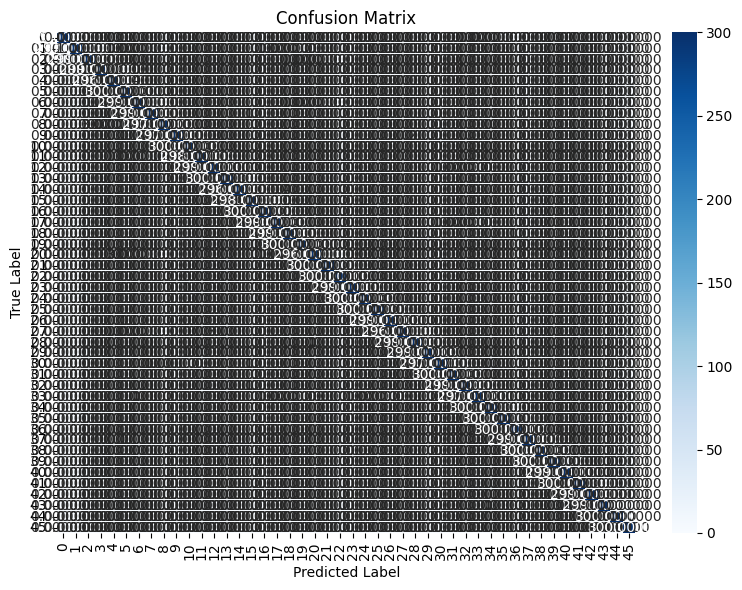

In [6]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

def compute_confusion_matrix(model: tf.keras.Model, dataset, NUM_CLASSES):
    """
    Compute and return confusion matrix from dataset predictions.
    Shape: (NUM_CLASSES, NUM_CLASSES) where rows=actual, cols=predicted.
    Now includes matplotlib visualization.
    """
    tp = np.zeros(NUM_CLASSES)
    fp = np.zeros(NUM_CLASSES)
    fn = np.zeros(NUM_CLASSES)

    # Track total predictions per class for confusion matrix
    conf_matrix = np.zeros((NUM_CLASSES, NUM_CLASSES))

    for images, labels in dataset:
        preds = tf.argmax(model(images, training=False), axis=1).numpy()
        lbls = labels.numpy()

        for i in range(len(preds)):
            actual = lbls[i]
            pred = preds[i]
            conf_matrix[actual, pred] += 1  # Direct count

            # Your original TP/FP/FN logic (for verification)
            for c in range(NUM_CLASSES):
                if pred == c and actual == c:
                    tp[c] += 1
                elif pred == c and actual != c:
                    fp[c] += 1
                elif pred != c and actual == c:
                    fn[c] += 1

    # Print confusion matrix
    print("Confusion Matrix (rows=actual, cols=predicted):")
    print(conf_matrix.astype(int))

    # Original macro F1 output
    prec = tp / (tp + fp + 1e-8)
    rec = tp / (tp + fn + 1e-8)
    f1 = 2 * prec * rec / (prec + rec + 1e-8)
    print(f"Macro Prec: {prec.mean()*100:.1f}%, Rec: {rec.mean()*100:.1f}%, F1: {f1.mean()*100:.1f}%")

    # MATPLOTLIB VISUALIZATION
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='f', cmap='Blues',
                xticklabels=range(NUM_CLASSES),
                yticklabels=range(NUM_CLASSES))
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    # plt.savefig('output/confusion_matrix.png')  # Save to output/ for sharing
    plt.show()

    return conf_matrix

# Usage (save to output/ directory as required)
cm = compute_confusion_matrix(model, test_ds, NUM_CLASSES)

In [ ]:
# Persist results
results_path = os.path.join(CFG["results_dir"], "tensorflow_results.json")
with open(results_path, "w") as f:
    json.dump(results, f, indent=2)
print(f"[INFO] Results  → {results_path}")

histories_path = os.path.join(CFG["results_dir"], "tensorflow_histories.json")
with open(histories_path, "w") as f:
    json.dump(
        {
            n: {k: [float(v) for v in vals] for k, vals in h.items()}
            for n, h in all_histories.items()
        },
        f, indent=2,
    )
print(f"[INFO] Histories → {histories_path}")

print(_c("\n[DONE] TensorFlow benchmark complete.\n", "green", "bold"))

[INFO] Results  → ./results/tensorflow_results.json
[INFO] Histories → ./results/tensorflow_histories.json

[DONE] TensorFlow benchmark complete.

